## Group Coursework: Replication of Rozeff & Kinney (1976)
## "Capital Market Seasonality: The Case of Stock Returns"

Replication using FTSE ALL SHARE data (1986-2025)
Segmented periods:
1. 1986–1999: Post-Big Bang market structure + stable period (Normal regime)
2. 2000–2008: Tech bubble + credit boom → high volatility (High-volatility regime)
3. 2009–2019: QE suppresses volatility, extremely calm (Unique stable regime)  
4. 2020–2025: Pandemic shock + inflation + rate hikes → regime change

Submitted by:
- VYFZ4 
- SKJJ3 
- RQRV8 
- VSMY4 
- YSUYO91
- XFCH2

In [4]:
# ====================
# 1. IMPORTS AND SETUP
# ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [8]:
# ====================
# 2. DATA LOADING AND PREPARATION
# ====================
print("Loading data...")

# Load the Excel file
# Note: Adjust the file path as needed
df = pd.read_excel('~/Downloads/data_fe_all.xlsx', sheet_name='Sheet1')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Display basic info
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Number of trading days: {len(df)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData info:")
print(df.info())

Loading data...
Data shape: (10154, 2)
Date range: 1986-01-01 00:00:00 to 2025-11-28 00:00:00
Number of trading days: 10154

First 5 rows:
             Price  Daily log return
Date                                
1986-01-01  682.94               NaN
1986-01-02  686.62          0.005374
1986-01-03  690.80          0.006069
1986-01-06  689.86         -0.001362
1986-01-07  685.36         -0.006544

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10154 entries, 1986-01-01 to 2025-11-28
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             10090 non-null  float64
 1   Daily log return  10031 non-null  float64
dtypes: float64(2)
memory usage: 238.0 KB
None


In [10]:
# ====================
# 3. DAILY TO MONTHLY CONVERSION
# ====================
print("\n" + "="*50)
print("CONVERTING DAILY TO MONTHLY DATA")
print("="*50)

# Ensure we have price data
if 'Daily log return' not in df.columns or df['Daily log return'].isnull().all():
    print("Calculating daily log returns from prices...")
    df['Daily log return'] = np.log(df['Price'] / df['Price'].shift(1))

# Resample to monthly data
# Using last trading day of month for price
monthly_prices = df['Price'].resample('M').last()
monthly_returns = df['Daily log return'].resample('M').sum()  # Sum of daily log returns = monthly log return

# Create monthly dataframe
monthly_df = pd.DataFrame({
    'Month_End_Price': monthly_prices,
    'Monthly_Log_Return': monthly_returns
})

# Calculate simple monthly returns (for some analyses)
monthly_df['Monthly_Simple_Return'] = np.exp(monthly_df['Monthly_Log_Return']) - 1

# Add month and year columns for analysis
monthly_df['Year'] = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.month
monthly_df['Month_Name'] = monthly_df.index.month_name()

print(f"Monthly data shape: {monthly_df.shape}")
print(f"Monthly data range: {monthly_df.index.min()} to {monthly_df.index.max()}")
print(f"Number of monthly observations: {len(monthly_df)}")

# Display monthly statistics
print("\nMonthly return statistics:")
print(f"Mean monthly log return: {monthly_df['Monthly_Log_Return'].mean():.4%}")
print(f"Std monthly log return: {monthly_df['Monthly_Log_Return'].std():.4%}")
print(f"Min monthly log return: {monthly_df['Monthly_Log_Return'].min():.4%}")
print(f"Max monthly log return: {monthly_df['Monthly_Log_Return'].max():.4%}")


CONVERTING DAILY TO MONTHLY DATA
Monthly data shape: (479, 6)
Monthly data range: 1986-01-31 00:00:00 to 2025-11-30 00:00:00
Number of monthly observations: 479

Monthly return statistics:
Mean monthly log return: 0.4198%
Std monthly log return: 4.3000%
Min monthly log return: -30.9241%
Max monthly log return: 12.5621%


In [12]:
# ====================
# 4. DEFINE TIME PERIODS (Following Rozeff & Kinney approach)
# ====================
print("\n" + "="*50)
print("DEFINING TIME PERIODS")
print("="*50)

def assign_regime(year, month):
    date = pd.Timestamp(year=year, month=month, day=1)
    
    # Regime 1: 1986-1999
    if date <= pd.Timestamp(year=1999, month=12, day=31):
        return {
            'Regime': 'Regime 1: 1986-1999',
            'Regime_Code': 1,
            'Description': 'Post-Big Bang market structure + stable period'
        }
    
    # Regime 2: 2000-2008
    elif date <= pd.Timestamp(year=2008, month=12, day=31):
        return {
            'Regime': 'Regime 2: 2000-2008',
            'Regime_Code': 2,
            'Description': 'Tech bubble + credit boom → high volatility'
        }
    
    # Regime 3: 2009-2019
    elif date <= pd.Timestamp(year=2019, month=12, day=31):
        return {
            'Regime': 'Regime 3: 2009-2019',
            'Regime_Code': 3,
            'Description': 'QE suppresses volatility, extremely calm'
        }
    
    # Regime 4: 2020-2025
    else:
        return {
            'Regime': 'Regime 4: 2020-2025',
            'Regime_Code': 4,
            'Description': 'Pandemic shock + inflation + rate hikes'
        }

# Apply regime assignment
regime_info = monthly_df.apply(lambda row: assign_regime(row.name.year, row.name.month), axis=1)
regime_df = pd.DataFrame(regime_info.tolist(), index=monthly_df.index)

# Merge with monthly data
monthly_df = pd.concat([monthly_df, regime_df], axis=1)

# Display regime statistics
print("\nRegime Distribution:")
print("-" * 80)

regime_summary = {}
for regime in monthly_df['Regime'].unique():  # 使用unique()方法
    regime_data = monthly_df[monthly_df['Regime'] == regime]
    
    # Basic statistics
    mean_ret = regime_data['Monthly_Log_Return'].mean()
    std_ret = regime_data['Monthly_Log_Return'].std()
    sharpe = mean_ret / std_ret * np.sqrt(12) if std_ret > 0 else np.nan
    
    # January effect
    january_data = regime_data[regime_data['Month'] == 1]['Monthly_Log_Return']
    other_data = regime_data[regime_data['Month'] != 1]['Monthly_Log_Return']
    jan_effect = january_data.mean() - other_data.mean() if len(january_data) > 0 else np.nan
    
    regime_summary[regime] = {
        'N': len(regime_data),
        'Mean_Return': mean_ret,
        'Std_Return': std_ret,
        'Sharpe_Ratio': sharpe,
        'January_Effect': jan_effect,
        'Description': regime_data['Description'].iloc[0]
    }
    
    # Print summary
    print(f"\n{regime}:")
    print(f"  Description: {regime_data['Description'].iloc[0]}")
    print(f"  Sample size: {len(regime_data)} months")
    print(f"  Mean monthly return: {mean_ret:.4%}")
    print(f"  Std monthly return: {std_ret:.4%}")
    print(f"  Sharpe ratio (annualized): {sharpe:.3f}")
    if not np.isnan(jan_effect):
        print(f"  January effect: {jan_effect:.4%}")

# Create summary DataFrame
summary_df = pd.DataFrame(regime_summary).T
print("\n" + "="*60)
print("REGIME SUMMARY TABLE")
print("="*60)
print(summary_df[['N', 'Mean_Return', 'Std_Return', 'Sharpe_Ratio', 'January_Effect']].round(4))


DEFINING TIME PERIODS

Regime Distribution:
--------------------------------------------------------------------------------

Regime 1: 1986-1999:
  Description: Post-Big Bang market structure + stable period
  Sample size: 168 months
  Mean monthly return: 0.9271%
  Std monthly return: 4.9546%
  Sharpe ratio (annualized): 0.648
  January effect: 2.1563%

Regime 2: 2000-2008:
  Description: Tech bubble + credit boom → high volatility
  Sample size: 108 months
  Mean monthly return: -0.3551%
  Std monthly return: 4.3231%
  Sharpe ratio (annualized): -0.285
  January effect: -2.5087%

Regime 3: 2009-2019:
  Description: QE suppresses volatility, extremely calm
  Sample size: 132 months
  Mean monthly return: 0.4749%
  Std monthly return: 3.4257%
  Sharpe ratio (annualized): 0.480
  January effect: -1.1431%

Regime 4: 2020-2025:
  Description: Pandemic shock + inflation + rate hikes
  Sample size: 71 months
  Mean monthly return: 0.2959%
  Std monthly return: 3.9494%
  Sharpe ratio (annu

In [14]:
# ====================
# 5. SAMPLE STATISTICS BY MONTH AND REGIME (Table 1 in original)
# ====================
print("\n" + "="*60)
print("SAMPLE STATISTICS BY MONTH AND REGIME (similar to Rozeff Table 1)")
print("="*60)

def calculate_statistics(data):
    """Calculate comprehensive statistics for a return series"""
    stats_dict = {}
    
    if len(data) == 0:
        return {k: np.nan for k in ['Mean', 'Median', '75%_Trunc_Mean', 'Std_Dev', 
                                    'Mean_Abs_Dev', 'Fama_Roll_d', 'Skewness', 'Kurtosis', 'N']}
    
    # Location measures
    stats_dict['Mean'] = data.mean()
    stats_dict['Median'] = data.median()
    
    # 75% truncated mean (Rozeff & Kinney method)
    sorted_data = np.sort(data)
    n = len(sorted_data)
    trim_count = int(0.125 * n)  # Trim 12.5% from each end = 75% middle
    if trim_count > 0 and n > 2 * trim_count:
        truncated_data = sorted_data[trim_count:-trim_count]
        stats_dict['75%_Trunc_Mean'] = truncated_data.mean()
    else:
        stats_dict['75%_Trunc_Mean'] = data.mean()
    
    # Scale measures
    stats_dict['Std_Dev'] = data.std()
    stats_dict['Mean_Abs_Dev'] = (data - data.mean()).abs().mean()
    
    # Fama-Roll dispersion measure (72nd - 28th fractile)/2*0.827
    if len(data) >= 4:
        p72 = np.percentile(data, 72)
        p28 = np.percentile(data, 28)
        stats_dict['Fama_Roll_d'] = (p72 - p28) / (2 * 0.827)
    else:
        stats_dict['Fama_Roll_d'] = np.nan
    
    # Higher moments
    stats_dict['Skewness'] = stats.skew(data)
    stats_dict['Kurtosis'] = stats.kurtosis(data)
    
    # Count
    stats_dict['N'] = len(data)
    
    return stats_dict

# Calculate statistics for each regime and month
regime_monthly_stats = {}
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

all_regime_stats = {}
for month in range(1, 13):
    month_data = monthly_df[monthly_df['Month'] == month]['Monthly_Log_Return']
    if len(month_data) > 0:
        all_regime_stats[month_names[month-1]] = calculate_statistics(month_data)

all_data = monthly_df['Monthly_Log_Return']
all_regime_stats['Overall'] = calculate_statistics(all_data)
regime_monthly_stats['All Regimes'] = all_regime_stats


for regime in monthly_df['Regime'].unique():
    regime_data = monthly_df[monthly_df['Regime'] == regime]
    regime_stats = {}
    
    # Statistics for each month
    for month in range(1, 13):
        month_data = regime_data[regime_data['Month'] == month]['Monthly_Log_Return']
        if len(month_data) > 0:
            regime_stats[month_names[month-1]] = calculate_statistics(month_data)
    
    # Overall regime statistics
    all_data = regime_data['Monthly_Log_Return']
    regime_stats['Overall'] = calculate_statistics(all_data)
    
    regime_monthly_stats[regime] = regime_stats

# Display statistics for each regime
for regime, stats_dict in regime_monthly_stats.items():
    print(f"\n{regime}:")
    print("-" * 80)
    
    # Create DataFrame for this regime
    stats_df = pd.DataFrame(stats_dict).T
    
    # Display key statistics
    display_cols = ['N', 'Mean', '75%_Trunc_Mean', 'Std_Dev', 'Fama_Roll_d', 'Skewness', 'Kurtosis']
    print(stats_df[display_cols].round(4))


SAMPLE STATISTICS BY MONTH AND REGIME (similar to Rozeff Table 1)

All Regimes:
--------------------------------------------------------------------------------
             N    Mean  75%_Trunc_Mean  Std_Dev  Fama_Roll_d  Skewness  \
Jan       40.0  0.0035          0.0047   0.0448       0.0261   -0.0175   
Feb       40.0  0.0091          0.0102   0.0390       0.0157   -0.2831   
Mar       40.0  0.0006          0.0048   0.0421       0.0264   -1.5391   
Apr       40.0  0.0183          0.0171   0.0320       0.0109    0.1649   
May       40.0  0.0035          0.0039   0.0338       0.0230    0.2682   
Jun       40.0 -0.0094         -0.0063   0.0347       0.0240   -0.5987   
Jul       40.0  0.0113          0.0136   0.0393       0.0275   -0.5544   
Aug       40.0 -0.0044         -0.0012   0.0429       0.0250   -0.6431   
Sep       40.0 -0.0097         -0.0067   0.0525       0.0297   -0.5321   
Oct       40.0 -0.0001          0.0109   0.0657       0.0293   -2.8393   
Nov       40.0  0.0068  


VISUAL INSPECTION BY REGIME


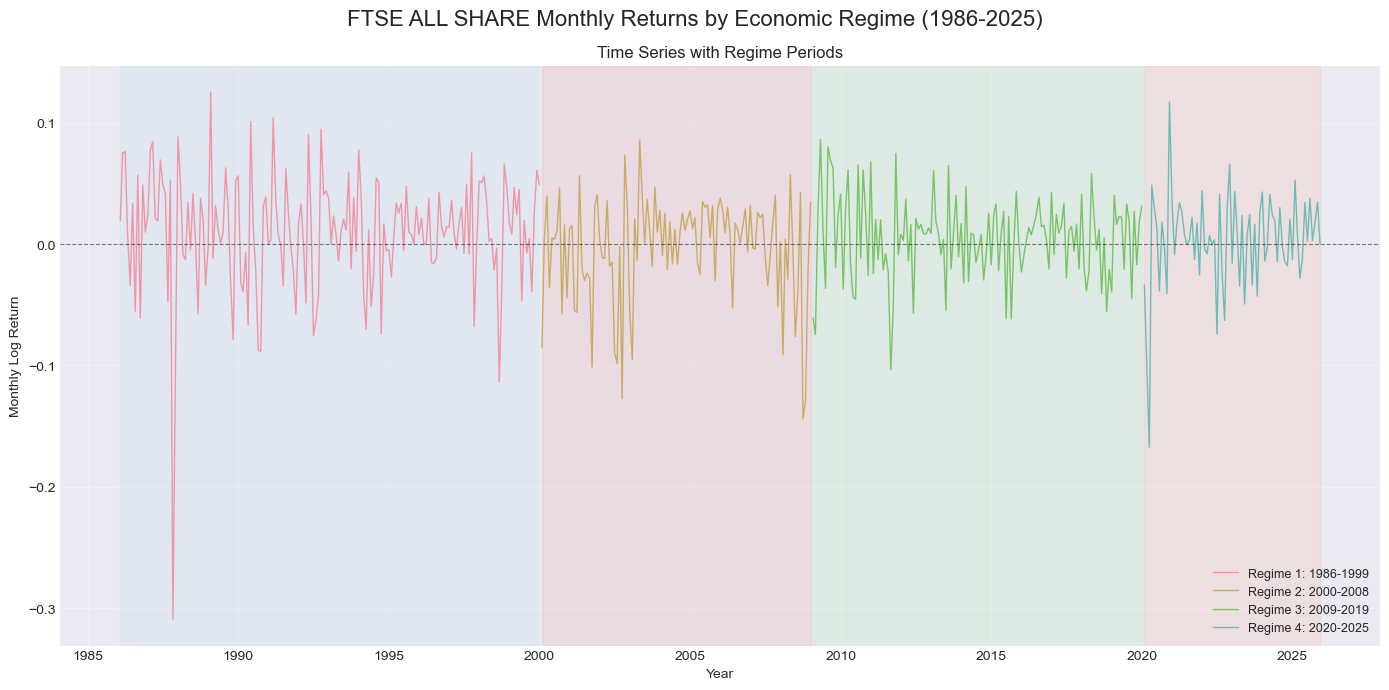

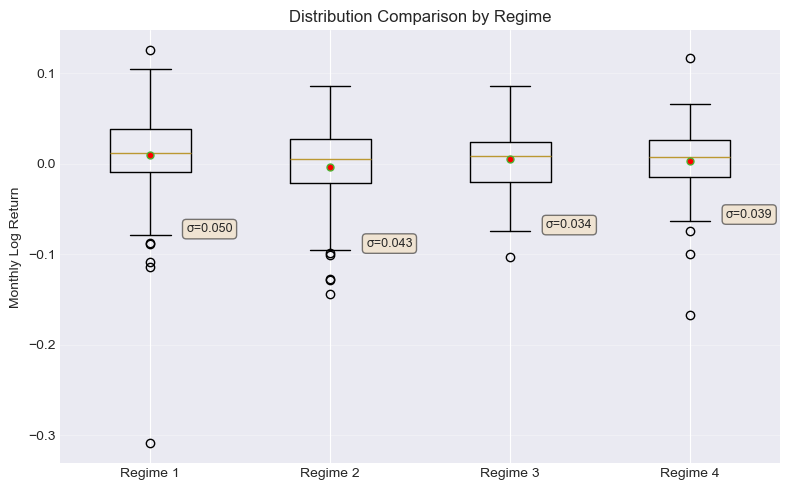

In [16]:
# ================================
# 6. VISUAL INSPECTION BY REGIME
# ================================
print("\n" + "="*60)
print("VISUAL INSPECTION BY REGIME")
print("="*60)

fig, ax = plt.subplots(1, 1, figsize=(14, 7))
fig.suptitle('FTSE ALL SHARE Monthly Returns by Economic Regime (1986-2025)',
             fontsize=16)

colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightsalmon']
regime_names = ['Regime 1: 1986-1999', 'Regime 2: 2000-2008',
                'Regime 3: 2009-2019', 'Regime 4: 2020-2025']

# 1. Time series with regime shading
for i, regime in enumerate(regime_names):
    if regime in monthly_df['Regime'].unique():
        regime_data = monthly_df[monthly_df['Regime'] == regime]
        ax.plot(regime_data.index, regime_data['Monthly_Log_Return'],
                label=regime, linewidth=1, alpha=0.7)

        start_date = regime_data.index.min()
        end_date   = regime_data.index.max()
        ax.axvspan(start_date, end_date, alpha=0.15, color=colors[i])

ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_title('Time Series with Regime Periods')
ax.set_ylabel('Monthly Log Return')
ax.set_xlabel('Year')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Distribution comparison by regime
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 5))
regime_data_list = []
regime_labels    = []

for regime in regime_names:
    if regime in monthly_df['Regime'].unique():
        regime_data_list.append(
            monthly_df[monthly_df['Regime'] == regime]['Monthly_Log_Return'])
        regime_labels.append(regime.split(":")[0])

box = ax2.boxplot(regime_data_list, labels=regime_labels,
                  showmeans=True,
                  meanprops={'marker':'o', 'markerfacecolor':'red', 'markersize':5})

for i, data in enumerate(regime_data_list):
    ax2.text(i+1.2, box['whiskers'][i*2].get_ydata()[1],
             f'σ={data.std():.3f}', fontsize=9, va='bottom',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2.set_title('Distribution Comparison by Regime')
ax2.set_ylabel('Monthly Log Return')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


AUTOCORRELATION FUNCTION ANALYSIS


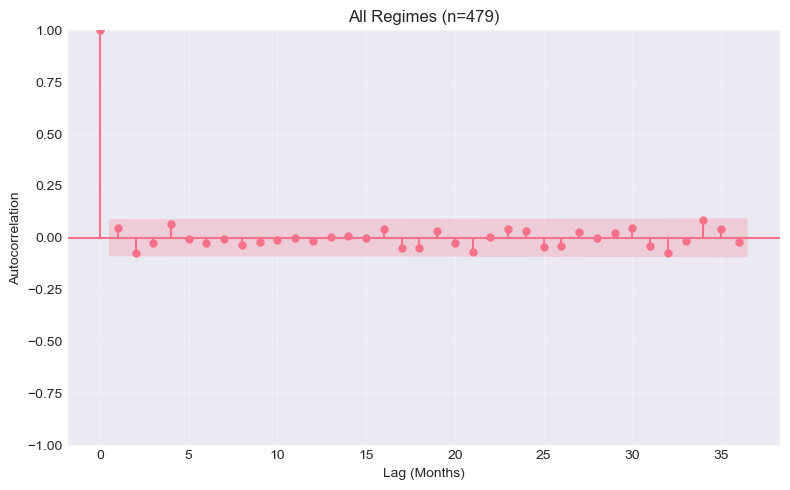

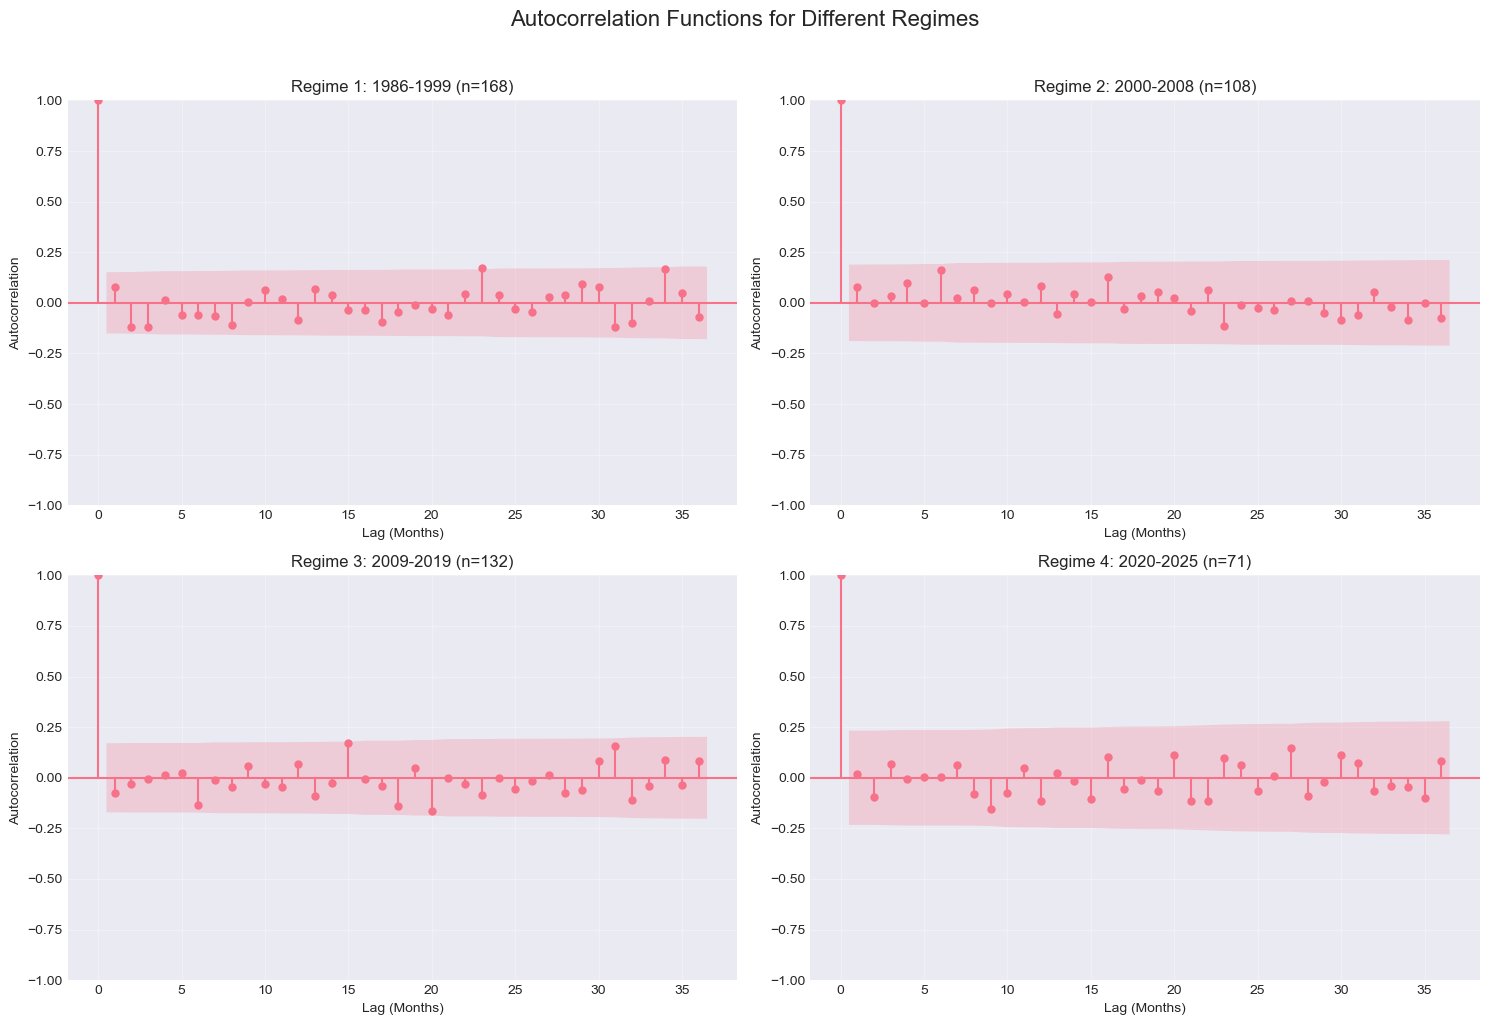

In [18]:
# ====================
# 7. AUTOCORRELATION FUNCTION
# ====================
print("\n" + "="*50)
print("AUTOCORRELATION FUNCTION ANALYSIS")
print("="*50)

import matplotlib.pyplot as plt
import statsmodels.api as sm

fig1, ax1 = plt.subplots(1, 1, figsize=(8, 5))
sm.graphics.tsa.plot_acf(
    monthly_df['Monthly_Log_Return'].dropna(),
    lags=36,
    ax=ax1,
    alpha=0.05
)
ax1.set_title('All Regimes '
              f'(n={len(monthly_df["Monthly_Log_Return"].dropna())})')
ax1.set_xlabel('Lag (Months)')
ax1.set_ylabel('Autocorrelation')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('autocorrelation_all_regime.png', dpi=300, bbox_inches='tight')
plt.show()

fig2, axes2 = plt.subplots(2, 2, figsize=(15, 10))
fig2.suptitle('Autocorrelation Functions for Different Regimes',
              fontsize=16, y=1.02)

regime_data = [
    ('Regime 1: 1986-1999',
     monthly_df[monthly_df['Regime'] == 'Regime 1: 1986-1999']['Monthly_Log_Return']),
    ('Regime 2: 2000-2008',
     monthly_df[monthly_df['Regime'] == 'Regime 2: 2000-2008']['Monthly_Log_Return']),
    ('Regime 3: 2009-2019',
     monthly_df[monthly_df['Regime'] == 'Regime 3: 2009-2019']['Monthly_Log_Return']),
    ('Regime 4: 2020-2025',
     monthly_df[monthly_df['Regime'] == 'Regime 4: 2020-2025']['Monthly_Log_Return']),
]

for idx, (title, data) in enumerate(regime_data):
    ax = axes2[idx // 2, idx % 2]
    sm.graphics.tsa.plot_acf(data.dropna(), lags=36, ax=ax, alpha=0.05)
    ax.set_title(f'{title} (n={len(data.dropna())})')
    ax.set_xlabel('Lag (Months)')
    ax.set_ylabel('Autocorrelation')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('autocorrelation_by_regimes_2x2.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# ====================
# 8. NON-PARAMETRIC TESTS (Section 4.4 in original)
# ====================
print("\n" + "="*50)
print("NON-PARAMETRIC TESTS")
print("="*50)

def kruskal_wallis_test_by_regime(data, regime_col='Regime'):
    """Perform Kruskal-Wallis test for each regime"""
    results = {}
    
    for regime in data[regime_col].unique():
        regime_data = data[data[regime_col] == regime]
        
        # Prepare data for Kruskal-Wallis test
        samples = []
        for month in range(1, 13):
            sample = regime_data[regime_data['Month'] == month]['Monthly_Log_Return'].dropna()
            if len(sample) > 0:
                samples.append(sample)
        
        if len(samples) >= 2:  # Need at least 2 groups
            stat, p_value = stats.kruskal(*samples)
            results[regime] = {
                'Statistic': stat,
                'p-value': p_value,
                'Significant_90': p_value < 0.10,
                'Significant_95': p_value < 0.05,
                'N_groups': len(samples)
            }
    
    return results

def siegel_tukey_test(data, regime_col='Regime'):
    """Perform Siegel-Tukey test for homogeneity of variances"""
    def siegel_tukey_statistic(samples):
        """Calculate Siegel-Tukey test statistic"""
        all_data = []
        group_labels = []
        
        for i, sample in enumerate(samples):
            all_data.extend(sample)
            group_labels.extend([i] * len(sample))
        
        df = pd.DataFrame({'value': all_data, 'group': group_labels})
        
        group_medians = df.groupby('group')['value'].median()
        df['adjusted'] = df.apply(lambda row: row['value'] - group_medians[row['group']], axis=1)
        
        df['abs_adjusted'] = df['adjusted'].abs()
        df = df.sort_values('abs_adjusted')
        
        n = len(df)
        ranks = np.zeros(n)
        
        low, high = 1, n
        for i in range(n):
            if i % 2 == 0: 
                ranks[i] = low
                low += 1
            else: 
                ranks[i] = high
                high -= 1
        
        df['rank'] = ranks
        
        rank_sums = df.groupby('group')['rank'].sum()
        
        return rank_sums
    
    results = {}
    
    for regime in data[regime_col].unique():
        regime_data = data[data[regime_col] == regime]
        
        samples = []
        for month in range(1, 13):
            sample = regime_data[regime_data['Month'] == month]['Monthly_Log_Return'].dropna()
            if len(sample) > 0:
                samples.append(sample)
        
        if len(samples) >= 2:
            rank_sums = siegel_tukey_statistic(samples)
            
            results[regime] = {
                'Rank_Sums': rank_sums.tolist(),
                'N_groups': len(samples)
            }
    
    return results

# Perform Kruskal-Wallis tests
print("Kruskal-Wallis Test Results (by Regime):")
print("-" * 60)
kw_results = kruskal_wallis_test_by_regime(monthly_df)

for regime, result in kw_results.items():
    sig_90 = "*" if result['Significant_90'] else ""
    sig_95 = "**" if result['Significant_95'] else ""
    print(f"{regime}: H = {result['Statistic']:.2f}, p = {result['p-value']:.4f} {sig_90}{sig_95}")

# Also test combined stable regimes (like Rozeff & Kinney's period 4)
print("\nKruskal-Wallis Test for Combined Stable Regimes (Regime 1 & 3):")
# 合并Regime 1和Regime 3（稳定时期）
stable_regimes = monthly_df[monthly_df['Regime_Code'].isin([1, 3])]
samples_combined = []
for month in range(1, 13):
    sample = stable_regimes[stable_regimes['Month'] == month]['Monthly_Log_Return'].dropna()
    if len(sample) > 0:
        samples_combined.append(sample)

if len(samples_combined) >= 2:
    stat_combined, p_combined = stats.kruskal(*samples_combined)
    sig_90 = "*" if p_combined < 0.10 else ""
    sig_95 = "**" if p_combined < 0.05 else ""
    print(f"H = {stat_combined:.2f}, p = {p_combined:.4f} {sig_90}{sig_95}")
    print(f"Sample size: {len(stable_regimes)} months")
else:
    print("Not enough data for combined analysis")

# 为All Regimes也进行Kruskal-Wallis检验
print("\nKruskal-Wallis Test for All Regimes Combined:")
samples_all = []
for month in range(1, 13):
    sample = monthly_df[monthly_df['Month'] == month]['Monthly_Log_Return'].dropna()
    if len(sample) > 0:
        samples_all.append(sample)

if len(samples_all) >= 2:
    stat_all, p_all = stats.kruskal(*samples_all)
    sig_90 = "*" if p_all < 0.10 else ""
    sig_95 = "**" if p_all < 0.05 else ""
    print(f"H = {stat_all:.2f}, p = {p_all:.4f} {sig_90}{sig_95}")
    print(f"Sample size: {len(monthly_df)} months")


NON-PARAMETRIC TESTS
Kruskal-Wallis Test Results (by Regime):
------------------------------------------------------------
Regime 1: 1986-1999: H = 9.21, p = 0.6024 
Regime 2: 2000-2008: H = 11.56, p = 0.3975 
Regime 3: 2009-2019: H = 16.44, p = 0.1257 
Regime 4: 2020-2025: H = 10.70, p = 0.4691 

Kruskal-Wallis Test for Combined Stable Regimes (Regime 1 & 3):
H = 16.66, p = 0.1184 
Sample size: 300 months

Kruskal-Wallis Test for All Regimes Combined:
H = 24.62, p = 0.0103 ***
Sample size: 479 months


In [22]:
# ====================
# 9. PARAMETRIC TESTS (Section 4.5 in original)
# ====================
print("\n" + "="*50)
print("PARAMETRIC TESTS")
print("="*50)

def bartlett_test_by_period(data, period_col='Regime'):
    """Perform Bartlett's test for homogeneity of variances"""
    results = {}
    
    for period in data[period_col].unique():
        period_data = data[data[period_col] == period]
        
        samples = []
        for month in range(1, 13):
            sample = period_data[period_data['Month'] == month]['Monthly_Log_Return'].dropna()
            if len(sample) > 0:
                samples.append(sample)
        
        if len(samples) >= 2:
            stat, p_value = stats.bartlett(*samples)
            results[period] = {
                'Statistic': stat,
                'p-value': p_value,
                'Significant_95': p_value < 0.05,
                'N_groups': len(samples)
            }
    
    return results

def anova_by_period(data, period_col='Regime'):
    """Perform ANOVA for each Regime"""
    results = {}
    
    for period in data[period_col].unique():
        period_data = data[data[period_col] == period].copy()
        
        # Remove months with insufficient data
        month_counts = period_data['Month'].value_counts()
        valid_months = month_counts[month_counts >= 3].index  # At least 3 observations
        period_data = period_data[period_data['Month'].isin(valid_months)]
        
        if len(valid_months) >= 2 and len(period_data) >= 10:
            # Convert month to categorical
            period_data['Month_Cat'] = pd.Categorical(period_data['Month'])
            
            # Fit ANOVA model
            model = ols('Monthly_Log_Return ~ C(Month_Cat)', data=period_data).fit()
            anova_table = anova_lm(model)
            
            results[period] = {
                'F_statistic': anova_table['F'][0],
                'p_value': anova_table['PR(>F)'][0],
                'df_model': anova_table['df'][0],
                'df_resid': anova_table['df'][1],
                'N': len(period_data),
                'N_groups': len(valid_months)
            }
    
    return results

# Perform Bartlett's tests
print("Bartlett's Test for Homogeneity of Variances:")
print("-" * 60)
bartlett_results = bartlett_test_by_period(monthly_df)

for period, result in bartlett_results.items():
    sig = "*" if result['Significant_95'] else ""
    print(f"{period}: χ² = {result['Statistic']:.2f}, p = {result['p-value']:.4f} {sig}")

# Perform ANOVA only for periods with homogeneous variances
print("\nANOVA Results (only for periods where variances are homogeneous):")
print("-" * 80)
anova_results = anova_by_period(monthly_df)

for period, result in anova_results.items():
    # Check if variances are homogeneous (p > 0.05 in Bartlett's test)
    bartlett_p = bartlett_results.get(period, {}).get('p-value', 1.0)
    
    if bartlett_p > 0.05:  # Variances are homogeneous
        sig_90 = "*" if result['p_value'] < 0.10 else ""
        sig_95 = "**" if result['p_value'] < 0.05 else ""
        sig_99 = "***" if result['p_value'] < 0.01 else ""
        
        print(f"{period}:")
        print(f"  F({result['df_model']},{result['df_resid']}) = {result['F_statistic']:.3f}, "
              f"p = {result['p_value']:.4f} {sig_90}{sig_95}{sig_99}")
        print(f"  N = {result['N']}, Groups = {result['N_groups']}")


PARAMETRIC TESTS
Bartlett's Test for Homogeneity of Variances:
------------------------------------------------------------
Regime 1: 1986-1999: χ² = 32.44, p = 0.0006 *
Regime 2: 2000-2008: χ² = 19.36, p = 0.0549 
Regime 3: 2009-2019: χ² = 8.39, p = 0.6780 
Regime 4: 2020-2025: χ² = 14.75, p = 0.1942 

ANOVA Results (only for periods where variances are homogeneous):
--------------------------------------------------------------------------------
Regime 2: 2000-2008:
  F(11.0,96.0) = 1.512, p = 0.1395 
  N = 108, Groups = 12
Regime 3: 2009-2019:
  F(11.0,120.0) = 1.762, p = 0.0682 *
  N = 132, Groups = 12
Regime 4: 2020-2025:
  F(11.0,59.0) = 1.074, p = 0.3972 
  N = 71, Groups = 12



MONTHLY ANALYSIS VISUALIZATION


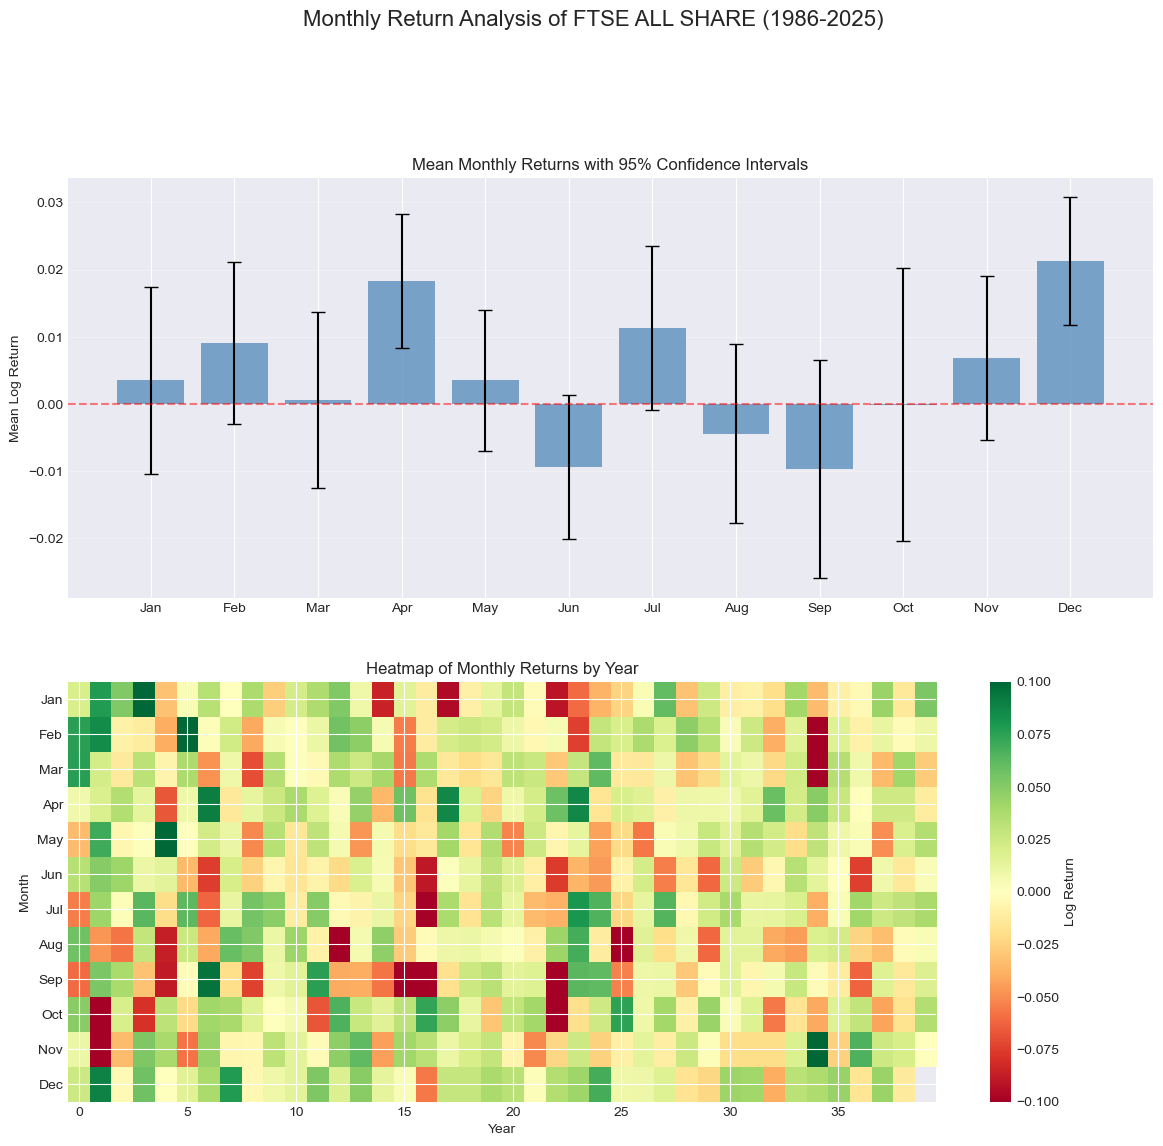

In [24]:
# ====================
# 10. VISUALIZATION BY MONTH (Similar to original paper)
# ====================
print("\n" + "="*50)
print("MONTHLY ANALYSIS VISUALIZATION")
print("="*50)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_order = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  # Month numbers in order

# Create a comprehensive monthly analysis plot
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Monthly Return Analysis of FTSE ALL SHARE (1986-2025)', fontsize=16, y=1.02)

# 1. Monthly means with confidence intervals
ax1 = axes[0]
monthly_stats = monthly_df.groupby('Month').agg({
    'Monthly_Log_Return': ['mean', 'std', 'count']
}).round(4)

monthly_stats.columns = ['Mean', 'Std', 'Count']
monthly_stats['SE'] = monthly_stats['Std'] / np.sqrt(monthly_stats['Count'])
monthly_stats['CI_lower'] = monthly_stats['Mean'] - 1.96 * monthly_stats['SE']
monthly_stats['CI_upper'] = monthly_stats['Mean'] + 1.96 * monthly_stats['SE']

x_pos = np.arange(1, 13)
ax1.bar(x_pos, monthly_stats['Mean'], yerr=1.96*monthly_stats['SE'], 
        capsize=5, alpha=0.7, color='steelblue')
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_names)
ax1.set_title('Mean Monthly Returns with 95% Confidence Intervals')
ax1.set_ylabel('Mean Log Return')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Heatmap of returns by month and year
ax2 = axes[1]
# Create pivot table for heatmap
heatmap_data = monthly_df.pivot_table(
    index='Year', 
    columns='Month', 
    values='Monthly_Log_Return',
    aggfunc='mean'
)

# Reorder columns
heatmap_data = heatmap_data[month_order]

im = ax2.imshow(heatmap_data.T, aspect='auto', cmap='RdYlGn', 
                vmin=-0.1, vmax=0.1)
ax2.set_title('Heatmap of Monthly Returns by Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Month')
ax2.set_yticks(np.arange(12))
ax2.set_yticklabels(month_names)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Log Return')


In [26]:
# ====================
# 11. COMPREHENSIVE MONTHLY EFFECTS ANALYSIS
# ====================
print("\n" + "="*70)
print("COMPREHENSIVE MONTHLY EFFECTS ANALYSIS")
print("="*70)

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. ==================== INDIVIDUAL MONTH EFFECTS ====================
print("\nINDIVIDUAL MONTH EFFECTS (vs All Other Months)")
print("-" * 70)

def test_individual_month_effects(data_df):
    """Test if each month's returns are significantly different from other months"""
    results = {}
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    for month_num in range(1, 13):
        month_data = data_df[data_df['Month'] == month_num]['Monthly_Log_Return'].dropna()
        other_data = data_df[data_df['Month'] != month_num]['Monthly_Log_Return'].dropna()
        
        if len(month_data) > 5:  # Minimum sample size
            # Calculate statistics
            month_mean = month_data.mean()
            other_mean = other_data.mean()
            diff = month_mean - other_mean
            
            # T-test
            t_stat, p_val = stats.ttest_ind(month_data, other_data, equal_var=False)
            
            # Calculate annualized difference
            annualized_diff = diff * 12
            
            # Store results
            results[month_names[month_num-1]] = {
                'Month_Mean': month_mean,
                'Other_Mean': other_mean,
                'Difference': diff,
                'Annualized_Diff': annualized_diff,
                't_stat': t_stat,
                'p_value': p_val,
                'Month_N': len(month_data),
                'Other_N': len(other_data),
                'Significant_10': p_val < 0.10,
                'Significant_5': p_val < 0.05,
                'Significant_1': p_val < 0.01
            }
    
    return pd.DataFrame(results).T

# Run for all data
all_months_results = test_individual_month_effects(monthly_df)
print("\nAll Regimes Combined (1986-2025):")
print(all_months_results[['Month_Mean', 'Other_Mean', 'Difference', 't_stat', 'p_value', 'Significant_5']].round(4))

# Run by regime
print("\n\nBy Economic Regime:")
for regime in monthly_df['Regime'].unique():
    regime_data = monthly_df[monthly_df['Regime'] == regime]
    regime_results = test_individual_month_effects(regime_data)
    
    # Find significant months
    sig_months = regime_results[regime_results['Significant_5']].index.tolist()
    
    print(f"\n{regime}:")
    if sig_months:
        print(f"  Significant months (5% level): {', '.join(sig_months)}")
        for month in sig_months[:3]:  # Show top 3
            row = regime_results.loc[month]
            print(f"    {month}: Diff={row['Difference']:.4f}, t={row['t_stat']:.3f}, p={row['p_value']:.4f}")
    else:
        print("  No significant monthly effects at 5% level")
    
    # Show best and worst months
    if not regime_results.empty:
        best_month = regime_results['Month_Mean'].idxmax()
        worst_month = regime_results['Month_Mean'].idxmin()
        print(f"  Highest mean: {best_month} ({regime_results.loc[best_month, 'Month_Mean']:.4%})")
        print(f"  Lowest mean: {worst_month} ({regime_results.loc[worst_month, 'Month_Mean']:.4%})")


COMPREHENSIVE MONTHLY EFFECTS ANALYSIS

INDIVIDUAL MONTH EFFECTS (vs All Other Months)
----------------------------------------------------------------------

All Regimes Combined (1986-2025):
    Month_Mean Other_Mean Difference    t_stat   p_value Significant_5
Jan   0.003515   0.004261  -0.000745 -0.101001  0.919991         False
Feb   0.009095   0.003752   0.005343  0.821187  0.415582         False
Mar   0.000564    0.00453  -0.003965 -0.568948  0.572114         False
Apr   0.018281   0.002915   0.015365  2.807345  0.006967          True
May   0.003545   0.004258  -0.000713 -0.124314  0.901548         False
Jun   -0.00942   0.005439  -0.014859  -2.53592  0.014327          True
Jul   0.011298   0.003551   0.007747  1.183533  0.242419         False
Aug  -0.004432   0.004985  -0.009417 -1.329137  0.190298         False
Sep  -0.009728   0.005467  -0.015196 -1.778816  0.082237         False
Oct  -0.000055   0.004586  -0.004641 -0.439427   0.66262         False
Nov   0.006815    0.00396

In [28]:
# ====================
# DECEMBER EFFECT PERSISTENCE ANALYSIS
# ====================
print("\n" + "="*70)
print("DECEMBER EFFECT PERSISTENCE ANALYSIS")
print("="*70)

# 1. Calculate rolling December effect
window_size = 60  #  5-year rolling window
dec_effect_rolling = []
rolling_dates = []
dec_means = []
other_means = []
dec_counts = []
other_counts = []

for i in range(window_size, len(monthly_df)):
    window_data = monthly_df.iloc[i-window_size:i]
    window_end_date = monthly_df.index[i-1]
    
    # December data
    dec_data = window_data[window_data['Month']==12]['Monthly_Log_Return']
    dec_mean = dec_data.mean()
    dec_count = len(dec_data)
    
    # Other months data
    other_data = window_data[window_data['Month']!=12]['Monthly_Log_Return']
    other_mean = other_data.mean()
    other_count = len(other_data)
    
    # Calculate effect
    dec_premium = dec_mean - other_mean
    
    # Store results
    dec_effect_rolling.append(dec_premium)
    rolling_dates.append(window_end_date)
    dec_means.append(dec_mean)
    other_means.append(other_mean)
    dec_counts.append(dec_count)
    other_counts.append(other_count)

# dataFrame
rolling_df = pd.DataFrame({
    'Window_End_Date': rolling_dates,
    'December_Premium': dec_effect_rolling,
    'December_Mean': dec_means,
    'Other_Months_Mean': other_means,
    'December_Count': dec_counts,
    'Other_Count': other_counts
})

rolling_df['Window_End_Date'] = pd.to_datetime(rolling_df['Window_End_Date'])
rolling_df['Year'] = rolling_df['Window_End_Date'].dt.year
rolling_df['Month'] = rolling_df['Window_End_Date'].dt.month

# 2. Output key statistics
print("\n1. Rolling December Effect - Overall Statistics:")
print("-" * 50)
print(f"Analysis period: {rolling_df['Window_End_Date'].min().date()} to {rolling_df['Window_End_Date'].max().date()}")
print(f"Number of rolling windows: {len(rolling_df)}")
print(f"December effect mean: {rolling_df['December_Premium'].mean():.6f} ({rolling_df['December_Premium'].mean()*100:.4f}%)")
print(f"December effect std: {rolling_df['December_Premium'].std():.6f}")
print(f"December effect median: {rolling_df['December_Premium'].median():.6f}")
print(f"Positive effect ratio: {(rolling_df['December_Premium'] > 0).sum()}/{len(rolling_df)} ({(rolling_df['December_Premium'] > 0).sum()/len(rolling_df)*100:.1f}%)")

#Statistical significance test
t_stat, p_value = stats.ttest_1samp(rolling_df['December_Premium'].dropna(), 0)
print(f"One-sample t-test (vs 0): t = {t_stat:.4f}, p = {p_value:.6f}")
sig_level = ""
if p_value < 0.01: sig_level = "***"
elif p_value < 0.05: sig_level = "**"
elif p_value < 0.10: sig_level = "*"
print(f"Significance level: {sig_level}")


DECEMBER EFFECT PERSISTENCE ANALYSIS

1. Rolling December Effect - Overall Statistics:
--------------------------------------------------
Analysis period: 1990-12-31 to 2025-10-31
Number of rolling windows: 419
December effect mean: 0.019002 (1.9002%)
December effect std: 0.011046
December effect median: 0.019653
Positive effect ratio: 391/419 (93.3%)
One-sample t-test (vs 0): t = 35.2133, p = 0.000000
Significance level: ***


In [30]:
# 3. Period analysis
print("\n\n2. December Effects in Different Periods:")
print("-" * 50)

def get_period(year):
    if year <= 1999:
        return "1986-1999"
    elif year <= 2008:
        return "2000-2008"
    elif year <= 2019:
        return "2009-2019"
    else:
        return "2020-2025"

rolling_df['Period'] = rolling_df['Year'].apply(get_period)

period_stats = []
for period in sorted(rolling_df['Period'].unique()):
    period_data = rolling_df[rolling_df['Period'] == period]
    
    if len(period_data) > 5: 
        mean_effect = period_data['December_Premium'].mean()
        std_effect = period_data['December_Premium'].std()
        pos_ratio = (period_data['December_Premium'] > 0).mean()
        
        # Within-period t-test
        t_stat_period, p_value_period = stats.ttest_1samp(period_data['December_Premium'].dropna(), 0)
        
        period_stats.append({
            'Period': period,
            'N_Windows': len(period_data),
            'Mean_Premium': mean_effect,
            'Std_Premium': std_effect,
            'Positive_Ratio': pos_ratio,
            't_stat': t_stat_period,
            'p_value': p_value_period,
            'Significant': p_value_period < 0.05
        })

period_stats_df = pd.DataFrame(period_stats)
print(period_stats_df.to_string(index=False))



2. December Effects in Different Periods:
--------------------------------------------------
   Period  N_Windows  Mean_Premium  Std_Premium  Positive_Ratio    t_stat      p_value  Significant
1986-1999        109      0.022070     0.007897        1.000000 29.178697 4.860081e-53         True
2000-2008        108      0.015823     0.008297        1.000000 19.818513 1.333943e-37         True
2009-2019        132      0.019118     0.015569        0.787879 14.107988 4.631575e-28         True
2020-2025         70      0.018912     0.006624        1.000000 23.886720 4.385535e-35         True


In [32]:
# 4. Structural break detection (Chow Test principle)
print("\n\n3. Structural break detection (Chow Test principle):")
print("-" * 50)

# Test changes around 2010 (start of QE)
break_year = 2010
pre_break = rolling_df[rolling_df['Year'] < break_year]['December_Premium']
post_break = rolling_df[rolling_df['Year'] >= break_year]['December_Premium']

print(f"Break year: {break_year}")

# Get actual time ranges
if len(pre_break) > 0:
    pre_years = rolling_df[rolling_df['Year'] < break_year]['Year']
    pre_start = pre_years.min() if len(pre_years) > 0 else 'N/A'
    pre_end = break_year - 1
    print(f"Pre-period ({pre_start}-{pre_end}):")
else:
    print(f"Pre-period (N/A-{break_year-1}):")

print(f"  Sample size: {len(pre_break)}")
if len(pre_break) > 0:
    print(f"  Mean:: {pre_break.mean():.6f} ({pre_break.mean()*100:.4f}%)")
    print(f"  Std: {pre_break.std():.6f}")
else:
    print(f"  Mean: N/A")
    print(f"  Std: N/A")

if len(post_break) > 0:
    post_years = rolling_df[rolling_df['Year'] >= break_year]['Year']
    post_start = break_year
    post_end = post_years.max() if len(post_years) > 0 else 'N/A'
    print(f"Post-period ({post_start}-{post_end}):")
else:
    print(f"Post-period ({break_year}-N/A):")

print(f"  Sample size: {len(post_break)}")
if len(post_break) > 0:
    print(f"  Mean: {post_break.mean():.6f} ({post_break.mean()*100:.4f}%)")
    print(f"  Std: {post_break.std():.6f}")
else:
    print(f"  Mean: N/A")
    print(f"  Std: N/A")

# Two-sample t-test
if len(pre_break) > 10 and len(post_break) > 10:
    t_stat_break, p_value_break = stats.ttest_ind(pre_break, post_break, equal_var=False)
    print(f"\nDifference test (pre vs post comparison):")
    print(f"  t-statistic: {t_stat_break:.4f}")
    print(f"  p-value: {p_value_break:.6f}")
    if p_value_break < 0.05:
        print(f"  → Conclusion: Structural break exists in {break_year} (p < 0.05)")
    else:
        print(f"  → Conclusion: No significant structural break detected")
elif len(pre_break) <= 10 or len(post_break) <= 10:
    print(f"\nWarning: Insufficient sample size for structural break test")
    print(f"  Pre-period sample: {len(pre_break)}")
    print(f"  Post-period sample: {len(post_break)}")



3. Structural break detection (Chow Test principle):
--------------------------------------------------
Break year: 2010
Pre-period (1990-2009):
  Sample size: 229
  Mean:: 0.019494 (1.9494%)
  Std: 0.008743
Post-period (2010-2025):
  Sample size: 190
  Mean: 0.018409 (1.8409%)
  Std: 0.013304

Difference test (pre vs post comparison):
  t-statistic: 0.9646
  p-value: 0.335491
  → Conclusion: No significant structural break detected


In [34]:
# 5. Trend analysis
print("\n\n4. December Effect Trend Analysis:")
print("-" * 50)

# Add time trend variable
rolling_df['Time_Index'] = np.arange(len(rolling_df))

# Linear trend regression
X = sm.add_constant(rolling_df['Time_Index'])
y = rolling_df['December_Premium']

model = sm.OLS(y, X).fit()
print("Linear trend model:")
print(f"   Intercept (initial effect): {model.params['const']:.6f} (p={model.pvalues['const']:.4f})")
print(f"  Slope (time trend): {model.params['Time_Index']:.8f} (p={model.pvalues['Time_Index']:.4f})")

if model.pvalues['Time_Index'] < 0.10:
    trend_direction = "increasing" if model.params['Time_Index'] > 0 else "decreasing"
    print(f"  → December effect shows significant {trend_direction} trend (per window change: {model.params['Time_Index']:.8f})")
else:
    print(f"  → December effect shows no significant time trend")



4. December Effect Trend Analysis:
--------------------------------------------------
Linear trend model:
   Intercept (initial effect): 0.023437 (p=0.0000)
  Slope (time trend): -0.00002122 (p=0.0000)
  → December effect shows significant decreasing trend (per window change: -0.00002122)


In [36]:
# 6. AUTOCORRELATION ANALYSIS (Corrected)
print("\n" + "="*70)
print("6. DECEMBER EFFECT AUTOCORRELATION ANALYSIS (Corrected)")
print("="*70)

print("\nNon-overlapping windows (one observation per year)")
print("-" * 60)

# Take one point per year (e.g., December window each year)
non_overlap_indices = np.arange(0, len(rolling_df), 12)  # One per year
non_overlap_series = rolling_df.iloc[non_overlap_indices]['December_Premium']

print(f"Non-overlapping windows: {len(non_overlap_series)}")
print(f"Time range: {rolling_df.iloc[non_overlap_indices[0]]['Window_End_Date'].year} - "
      f"{rolling_df.iloc[non_overlap_indices[-1]]['Window_End_Date'].year}")

# Calculate autocorrelation coefficients (max lag 5 years)
max_lag_nonoverlap = min(5, len(non_overlap_series) - 1)
if max_lag_nonoverlap >= 1:
    acf_nonoverlap = sm.tsa.acf(non_overlap_series.dropna(), 
                                 nlags=max_lag_nonoverlap, 
                                 fft=False)
    
    print("\nAutocorrelation coefficients (non-overlapping, lags 1-5 years):")
    for lag in range(1, len(acf_nonoverlap)):
        print(f"  Lag {lag} ({lag} years): {acf_nonoverlap[lag]:.4f}")
        
    # Ljung-Box test
    if len(non_overlap_series) > 10:
        lb_test_nonoverlap = sm.stats.acorr_ljungbox(non_overlap_series.dropna(), 
                                                     lags=[3], 
                                                     return_df=True)
        print(f"\nLjung-Box test (lag 3):")
        print(f"  Q-statistic: {lb_test_nonoverlap['lb_stat'].iloc[0]:.4f}")
        print(f"  p-value: {lb_test_nonoverlap['lb_pvalue'].iloc[0]:.4f}")
        
        if lb_test_nonoverlap['lb_pvalue'].iloc[0] < 0.05:
            print("  → Conclusion: December effect shows significant inter-annual autocorrelation")
        else:
            print("  → Conclusion: December effect shows no significant inter-annual autocorrelation")
else:
    print("Insufficient sample size for non-overlapping autocorrelation analysis")


6. DECEMBER EFFECT AUTOCORRELATION ANALYSIS (Corrected)

Non-overlapping windows (one observation per year)
------------------------------------------------------------
Non-overlapping windows: 35
Time range: 1990 - 2024

Autocorrelation coefficients (non-overlapping, lags 1-5 years):
  Lag 1 (1 years): 0.6523
  Lag 2 (2 years): 0.3881
  Lag 3 (3 years): 0.1598
  Lag 4 (4 years): -0.1653
  Lag 5 (5 years): -0.5040

Ljung-Box test (lag 3):
  Q-statistic: 23.1537
  p-value: 0.0000
  → Conclusion: December effect shows significant inter-annual autocorrelation




7. COMPREHENSIVE VISUALIZATION:
--------------------------------------------------


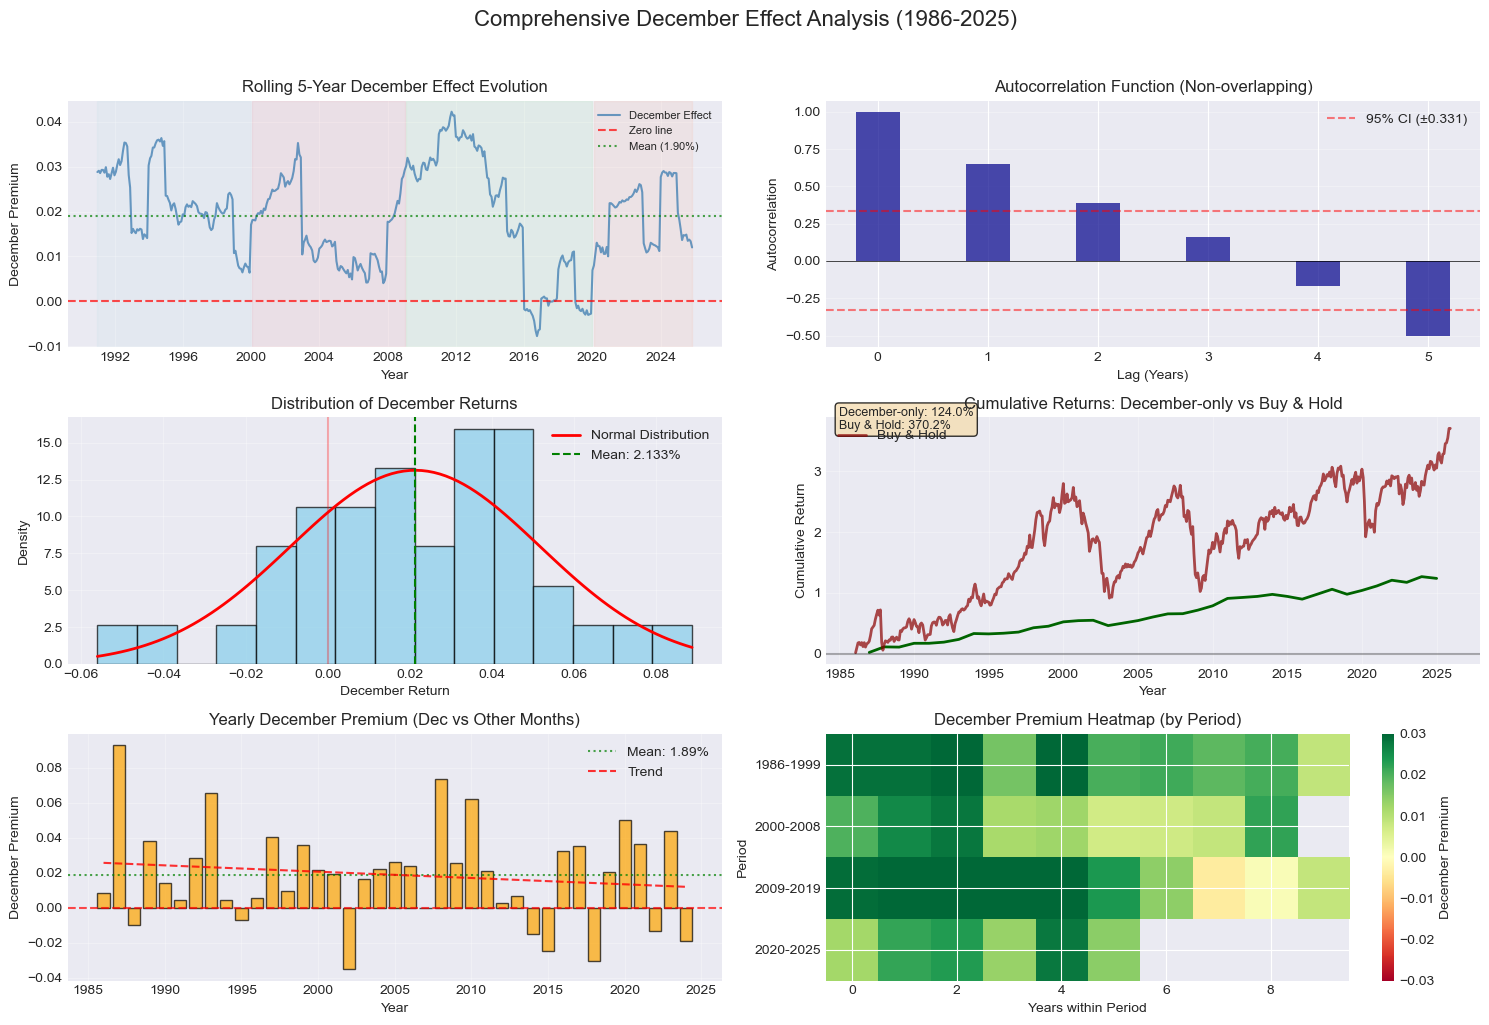

In [40]:
# 8. COMPREHENSIVE VISUALIZATION
print("\n\n7. COMPREHENSIVE VISUALIZATION:")
print("-" * 50)

december_returns = monthly_df[monthly_df['Month'] == 12]['Monthly_Log_Return']

# yearly_dec_premium price
yearly_dec_premium = []
years_list = []
for year in range(monthly_df.index.year.min(), monthly_df.index.year.max() + 1):
    year_data = monthly_df[monthly_df.index.year == year]
    if len(year_data) >= 12:  
        dec_return = year_data[year_data['Month'] == 12]['Monthly_Log_Return']
        other_returns = year_data[year_data['Month'] != 12]['Monthly_Log_Return']
        
        if len(dec_return) > 0 and len(other_returns) > 0:
            premium = dec_return.mean() - other_returns.mean()
            yearly_dec_premium.append(premium)
            years_list.append(year)

yearly_premium_series = pd.Series(yearly_dec_premium, index=years_list)

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Comprehensive December Effect Analysis (1986-2025)', fontsize=16, y=1.02)

colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightsalmon']

# 8.1 Rolling December effect
ax1 = axes[0, 0]
ax1.plot(rolling_df['Window_End_Date'], rolling_df['December_Premium'], 
         label='December Effect', linewidth=1.5, alpha=0.8, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero line')
ax1.axhline(y=rolling_df['December_Premium'].mean(), color='green', 
           linestyle=':', alpha=0.7, label=f'Mean ({rolling_df["December_Premium"].mean()*100:.2f}%)')

# Add regime shading
for i, period in enumerate(rolling_df['Period'].unique()):
    period_data = rolling_df[rolling_df['Period'] == period]
    if len(period_data) > 0:
        start_date = period_data['Window_End_Date'].min()
        end_date = period_data['Window_End_Date'].max()
        ax1.axvspan(start_date, end_date, alpha=0.1, color=colors[i])

ax1.set_title('Rolling 5-Year December Effect Evolution')
ax1.set_xlabel('Year')
ax1.set_ylabel('December Premium')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# 8.2 Autocorrelation function
ax2 = axes[0, 1]
if 'acf_nonoverlap' in locals():
    lags = np.arange(len(acf_nonoverlap))
    ax2.bar(lags, acf_nonoverlap, width=0.4, alpha=0.7, color='darkblue')
    ax2.axhline(y=0, color='black', linewidth=0.5)
    
    # Add confidence bands
    n_acf = len(non_overlap_series)
    conf_int = 1.96 / np.sqrt(n_acf)
    ax2.axhline(y=conf_int, color='red', linestyle='--', alpha=0.5, label=f'95% CI (±{conf_int:.3f})')
    ax2.axhline(y=-conf_int, color='red', linestyle='--', alpha=0.5)
    
    ax2.set_title('Autocorrelation Function (Non-overlapping)')
    ax2.set_xlabel('Lag (Years)')
    ax2.set_ylabel('Autocorrelation')
    ax2.set_xticks(lags)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

# 8.3 December returns distribution
ax3 = axes[1, 0]
if len(december_returns) > 0:
    ax3.hist(december_returns, bins=15, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    
    # Add normal distribution for comparison
    x = np.linspace(december_returns.min(), december_returns.max(), 100)
    pdf = stats.norm.pdf(x, december_returns.mean(), december_returns.std())
    ax3.plot(x, pdf, 'r-', linewidth=2, label='Normal Distribution')
    
    ax3.axvline(x=december_returns.mean(), color='green', linestyle='--', 
               label=f'Mean: {december_returns.mean():.3%}')
    ax3.axvline(x=0, color='red', linestyle='-', alpha=0.3)
    
    ax3.set_title('Distribution of December Returns')
    ax3.set_xlabel('December Return')
    ax3.set_ylabel('Density')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 8.4 Cumulative December-only returns
ax4 = axes[1, 1]
if len(december_returns) > 0:
    # Calculate cumulative returns for December-only strategy
    dec_cumulative = (1 + december_returns).cumprod() - 1
    ax4.plot(december_returns.index, dec_cumulative, linewidth=2, color='darkgreen')
    
    # Calculate buy-and-hold for comparison
    all_cumulative = (1 + monthly_df['Monthly_Log_Return']).cumprod() - 1
    ax4.plot(all_cumulative.index, all_cumulative, linewidth=2, color='darkred', alpha=0.7, label='Buy & Hold')
    
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax4.set_title('Cumulative Returns: December-only vs Buy & Hold')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Cumulative Return')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Add final values
    if len(dec_cumulative) > 0:
        final_dec = dec_cumulative.iloc[-1]
        final_all = all_cumulative.iloc[-1] if len(all_cumulative) > 0 else 0
        ax4.text(0.02, 0.95, f'December-only: {final_dec*100:.1f}%\nBuy & Hold: {final_all*100:.1f}%', 
                transform=ax4.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 8.5 Yearly December premium time series
ax5 = axes[2, 0]
if len(yearly_premium_series) > 0:
    ax5.bar(yearly_premium_series.index, yearly_premium_series.values, 
            alpha=0.7, color='orange', edgecolor='black')
    ax5.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    ax5.axhline(y=yearly_premium_series.mean(), color='green', linestyle=':', 
               alpha=0.7, label=f'Mean: {yearly_premium_series.mean()*100:.2f}%')
    
    # Add trend line
    if len(yearly_premium_series) > 2:
        z = np.polyfit(yearly_premium_series.index, yearly_premium_series.values, 1)
        p = np.poly1d(z)
        ax5.plot(yearly_premium_series.index, p(yearly_premium_series.index), 
                "r--", alpha=0.8, label='Trend')
    
    ax5.set_title('Yearly December Premium (Dec vs Other Months)')
    ax5.set_xlabel('Year')
    ax5.set_ylabel('December Premium')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 8.6 Heatmap of December effect by period and time
ax6 = axes[2, 1]
# Prepare data for heatmap
heatmap_data = []
period_labels = []

for period in rolling_df['Period'].unique():
    period_data = rolling_df[rolling_df['Period'] == period]
    if len(period_data) > 0:
        # Calculate average premium by year within period
        yearly_avg = period_data.groupby('Year')['December_Premium'].mean()
        heatmap_data.append(yearly_avg.values[:10])  # Take first 10 years for consistency
        period_labels.append(period.split(':')[0] if ':' in period else period)

if len(heatmap_data) > 0:
    # Ensure all rows have same length
    max_len = max(len(row) for row in heatmap_data)
    heatmap_data_padded = []
    for row in heatmap_data:
        padded_row = np.pad(row, (0, max_len - len(row)), constant_values=np.nan)
        heatmap_data_padded.append(padded_row)
    
    heatmap_matrix = np.array(heatmap_data_padded)
    
    im = ax6.imshow(heatmap_matrix, aspect='auto', cmap='RdYlGn', 
                    vmin=-0.03, vmax=0.03)
    
    ax6.set_title('December Premium Heatmap (by Period)')
    ax6.set_xlabel('Years within Period')
    ax6.set_ylabel('Period')
    ax6.set_yticks(np.arange(len(period_labels)))
    ax6.set_yticklabels(period_labels)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax6)
    cbar.set_label('December Premium')

plt.tight_layout()
plt.savefig('december_effect_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()